In [1]:
# import packages, declare constants, get the parent directory
import pandas as pd
import numpy as np
import re
import os
import time
import decimal
from scipy import stats
#from wordcloud import WordCloud
import matplotlib.pyplot as plt
from matplotlib import colormaps
#from .utils import helpers
#import simplemma
import pyvoikko

CHATGPT_RELEASE_YEAR = int(2022)
FINNISH_ALPHABET = 'abcdefghijklmnopqrstuvwxyzåäö'

def get_parent_directory() -> str:
    """Get the parent directory for handling csv files.

    Returns:
        string: the path to the directory where directories for csv files are located
    """
    #create relative path for parent
    relative_parent = os.path.join(os.getcwd(), '..')

    #use abspath for absolute parent path
    return str(os.path.abspath(relative_parent)).replace('\\', '/')

directory = get_parent_directory()

DECLARE FUNCTIONS

In [2]:
def clean_string(string: str) -> str:
    try:
        # remove blanks in start and end
        string = string.strip()
        string = string.lower()
        # the string must contain characters
        if any(c in string for c in FINNISH_ALPHABET)==False:
            string = ''
        # remove tabulations, line breaks etc., also special characters
        remove_these = r'[\+\*!"”’?.:,…()§\'[\] \t\n\r\f\v]'
        string = re.sub(remove_these, '', string)
        # remove weird parentheses and backwards linebreaks from starts of strings
        string = re.sub(r'^\)\\[a-z]', '', string)
        # remove weird '\[alphabet]' strings at start of strings
        string = re.sub(r'^\\[a-z]', '', string)
        # remove numbers
        string = re.sub(r'[0-9]', '', string)
        # remove dashes '-' at the start and end of string
        string = re.sub(r'^-|-$', '', string)
        # remove individual forward and backward slashes '/', '\'
        string = re.sub(r'[\/\\]', '', string)
        # remove double dashes '--'
        string = string.replace('--', '-')
        # remove the equal sign '='
        string = string.replace('=', '')
        # at the end of the cleaning, remove all characters from the string which are not in the alphabet except for dash (compound words)
        remove_these = ''.join([str(c) for c in string if c != '-' and c not in [i for i in FINNISH_ALPHABET]])
        string = re.sub(remove_these, '', string)
        # remove blanks in start and end again
        string = string.strip()
        # remove empty if string length < 2
        string = '' if len(string) < 2 else string
        return string
    except:
        print(f'Unexpected error at helpers.clean_string(), string: {string}')
        raise

In [3]:
def count_word_freqs_in_string(string: str):
    """Counts the words in the input string.
    Returns a dictionary where the word is the key and the frequency is the value.
    """
    if ((string is None) or (string == 'nan')):
        return None
    else:
        words_list = re.split(' ', string)
        wordfreq_dict = {}
        for word in words_list:
            if word not in wordfreq_dict.keys():
                wordfreq_dict[word] = 1
            else:
                wordfreq_dict[word] += 1

        return wordfreq_dict

In [4]:
def get_normalised(df: pd.DataFrame, speaker_id: str, year: int, word_n: int) -> float:
    w_min = df['word_n'].loc[(df['speaker_id']==speaker_id)&(df['year']==year)].min()
    w_max = df['word_n'].loc[(df['speaker_id']==speaker_id)&(df['year']==year)].max()
    return ((word_n-w_min)/(w_max-w_min))

In [5]:
def linear_extrapolation(y: list, x: list, n=1) -> list:
    """Linear extrapolation based on last two x and y observations. Returns the extrapolated value of y for a given x based on y1x1 and y2x2.
    Parameter x will be standardised to a running sequence of numbers so extrapolations works on a linear scale.
    Args:
        y (list): list of values
        x (list): list of values
        n (int, optional): for how many times shall extrapolation be done. Defaults to 1. Larger values will start extrapolating on extrapolated values.

    Returns:
        list: extrapolated value(s) of y. The length of the list will be n.
    """
    # x and y must be arrays of same length
    # CHANGE THIS TO ASSERT
    if len(y) != len(x):
        print('array length mismatch')
        return None
    else:
        # format helper parameters to not modify lists outside the function
        xx = [*[i for i in x]]
        yy = [*[i for i in y]]
        return_list = [] # format list to be returned
        # loop n times -> return list of n length with n extrapolations
        # note: extrapolating on extrapolations if n>1
        while n >= 1:
            # format xx: it shall take a running sequence of numbers as its values
            xx = [i for i in range(len(x))]
            m = (yy[-1] - yy[-2]) / (xx[-1] - xx[-2])
            y_v = yy[-2] + m * ((xx[-1] + 1) - xx[-2])
            xx.append([xx[-1]+1])
            yy.append(y_v)
            return_list.append(y_v)
            n = n-1
        return return_list

In [6]:
## lemmatised csvs
df_speech_lengths = pd.read_csv(f'{directory}/csv_analysis/speaker_speech_lengths.csv', sep=';', header=0, encoding='utf-8')
df_speeches_combined_length = pd.read_csv(f'{directory}/csv_analysis/speeches_combined_plus_length.csv', sep=';', header=0, encoding='utf-8', dtype=str)
df_speaker_words_year = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp.csv', sep=';', header=0, encoding='utf-8')
df_speaker_words_data = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_wide.csv', sep=';', header=0, encoding='utf-8')

In [ ]:
# VISUALISATION
# the minimum length of of speeches HAS increased insce the relase of chatgpt, although not by much
# plug in means and maxes, not much change there
x = df_speech_lengths['year'].unique()

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, sharex=True)

def plot_mins():
    avg_min = []
    for year in df_speech_lengths['year'].unique():
        avg_min.append(df_speech_lengths['len_min'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_min = df_speech_lengths['len_min'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax1.plot(x, y_min, color='grey', linestyle='dashed', linewidth=1)

    ax1.plot(x, avg_min, '.-', color='red')

    ax1.title.set_text('minimum amount of words in a speech')
    ax1.set_ylabel('words')

def plot_maxs():
    avg_max = []
    for year in df_speech_lengths['year'].unique():
        avg_max.append(df_speech_lengths['len_max'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_max = df_speech_lengths['len_max'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax2.plot(x, y_max, color='grey', linestyle='dashed', linewidth=1)

    ax2.plot(x, avg_max, '.-', color='red')

    ax2.title.set_text('maximum amount of words in a speech')
    ax2.set_ylabel('words')

def plot_means():
    avg_mean = []
    for year in df_speech_lengths['year'].unique():
        avg_mean.append(df_speech_lengths['len_mean'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_mean = df_speech_lengths['len_mean'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax3.plot(x, y_mean, color='grey', linestyle='dashed', linewidth=1)

    ax3.plot(x, avg_mean, '.-', color='red')

    ax3.title.set_text('mean amount of words in a speech')
    ax3.set_ylabel('words')
    ax3.set_xlabel('year')

def plot_medians():
    avg_median = []
    for year in df_speech_lengths['year'].unique():
        avg_median.append(df_speech_lengths['len_median'].loc[df_speech_lengths['year']==year].median())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_mean = df_speech_lengths['len_median'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax4.plot(x, y_mean, color='grey', linestyle='dashed', linewidth=1)

    ax4.plot(x, avg_median, '.-', color='red')

    ax4.title.set_text('median amount of words in a speech')
    ax4.set_ylabel('words')
    ax4.set_xlabel('year')

def plot_total():
    avg_total = []
    for year in df_speech_lengths['year'].unique():
        avg_total.append(df_speech_lengths['words_total'].loc[df_speech_lengths['year']==year].mean())

    for speaker in df_speech_lengths['speaker_id'].unique():
        y_total = df_speech_lengths['words_total'][df_speech_lengths['speaker_id']==speaker].tolist()
        ax5.plot(x, y_total, color='grey', linestyle='dashed', linewidth=1)

    ax5.plot(x, avg_total, '.-', color='red')

    ax5.title.set_text('total amount of words in a speech')
    ax5.set_ylabel('words')
    ax5.set_xlabel('year')    
 
for ax in fig.get_axes():
    ax.label_outer()

fig.set_figheight(10)
fig.set_figwidth(10)
fig.set_constrained_layout(constrained=True)
plot_mins()
plot_maxs()
plot_means()
plot_medians()
plot_total()

plt.xticks(df_speech_lengths['year'].unique())
plt.show()

In [ ]:
x = df_speech_lengths['year'].unique()

def plot_total_bar():
    y_total_bar = []
    for year in df_speech_lengths['year'].unique():
        y_total_bar.append(df_speech_lengths['words_total'].loc[df_speech_lengths['year']==year].sum())

    plt.bar(x, height=y_total_bar)
    plt.title('total amount of words per year')
    plt.ylabel('words')
    plt.xlabel('year')  

plot_total_bar()
plt.xticks(df_speech_lengths['year'].unique())
plt.show()

In [ ]:
years = [re.search(r'\d+', i)[0] for i in df_speaker_words_data.columns if re.search(r'word_n_\d+', i)]
# define set colors for each word class across multiple pie charts
colours = {}
cm = iter(colormaps['tab20c'].colors)
for c in df_speaker_words_data['word_class'].unique():
    colours[c] = next(cm)
for year in years:
    plot_this = pd.DataFrame(columns=['year','class','n']).astype({'year':int,'class':str,'n':int})
    classes = df_speaker_words_data['word_class'].loc[df_speaker_words_data[f'word_n_{year}'].notna()].unique()
    l = []
    for c in classes:
        l.append(c)
        plot_this = pd.concat([plot_this, pd.DataFrame.from_dict({'year':[year],'class':[c],'n':[df_speaker_words_data[f'word_norm_{year}'].loc[(df_speaker_words_data[f'word_norm_{year}'].notna())&(df_speaker_words_data['word_class']==c)].sum()]})])
    plt.pie(x=plot_this['n'], labels=l, autopct='%1.1f%%', colors=[colours[i] for i in [i for i in l]])
    plt.title(year)
    plt.show()

In [8]:
# VISUALISATION (NONLEMMATISED): 
# plot the words, that have an increased normalised frequency in 2024 and 2025 compared to 2015-2022 (let's try this first)
## get the words 
df_speaker_words_data = pd.read_csv(f'{directory}/csv_analysis/speaker_words_comp_wide.csv', sep=';', header=0, encoding='utf-8')
## clean the word string one more time
df_speaker_words_data['word'] = df_speaker_words_data['word'].apply(clean_string)
## create a df which to plot
plot_this = pd.DataFrame(columns=['year','word','word_n','word_norm']).astype({'year':int, 'word':str, 'word_n':int, 'word_norm':float})

## populate the df
for year in [re.search(r'\d+', i)[0] for i in df_speaker_words_data.columns if re.search(r'word_norm_\d+', i)]:
    # summarise word counts per each year in a temporary df
    word_counts = df_speaker_words_data.groupby("word")[f'word_n_{year}'].sum().reset_index()
    word_counts = word_counts.rename(columns={f'word_n_{year}': 'word_n'})
    word_counts['year'] = int(year)
    word_counts['word_norm'] = None
    # normalise using min-maxing -> save in column 'word_norm'
    min_max = word_counts.groupby("year")["word_n"].agg(["min", "max"]).reset_index()
    word_counts = word_counts.merge(min_max, on='year', suffixes=('', '_stats'))
    word_counts['word_norm'] = ((word_counts['word_n']-word_counts['min'])/(word_counts['max']-word_counts['min']))
    word_counts = word_counts.drop(columns=["min", "max"])
    # concat the temp df to the final plottable df
    plot_this = pd.concat([plot_this, word_counts], axis=0, ignore_index=True)

## extract words which have increased in normalised frequency (higher word_norm in 2024, 2025 relative to 2015-2022)
### divide plot_this into 2 dataframes: one for years 2024-2025, and one for years before that
later_df = plot_this.loc[plot_this['year'].isin([2024, 2025])]
earlier_df = plot_this.loc[~plot_this['year'].isin([2024, 2025])]
later_df = later_df.loc[later_df['word'].isin(earlier_df['word'])]
later_df = later_df.merge(earlier_df[['word', 'word_norm']], on='word', suffixes=('', '_e'))
later_df = later_df[later_df['word_norm'] > later_df['word_norm_e']]
later_df = later_df.drop(columns=['word_norm_e'])
later_df = later_df.drop_duplicates()

plot_this = plot_this.loc[plot_this['word'].isin(later_df['word'])]

In [ ]:
x = plot_this['year'].unique()
top_words = plot_this.groupby("word")["word_n"].sum().nlargest(100).index
df_top = plot_this[plot_this["word"].isin(top_words)]
for word in df_top['word'].unique():
    y = df_top['word_n'][df_top['word']==word]
    plt.plot(x, y, label=word, linestyle='-', color='grey')

plt.show()

In [ ]:
x = plot_this['year'].unique()
for word in plot_this['word'].unique():
    y = plot_this['word_norm'].loc[plot_this['word']==word]
    plt.plot(x, y, label=word, linestyle='-', color='grey')

plt.xticks(plot_this['year'].unique())
plt.show()

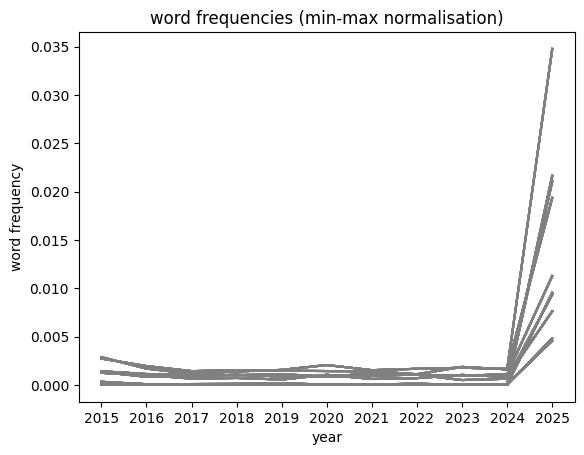

In [16]:
# x-axis = years
x = plot_this['year'].unique()

# y-axis: word_norm
# limit only to top N words, where the difference between (2024,2025) > (years before) is the largest
later_df = plot_this.loc[plot_this['year'].isin([2024, 2025])]
earlier_df = plot_this.loc[~plot_this['year'].isin([2024, 2025])]

# order the words in later_df, descending based on the difference between word_norm values
earlier_word_norm_sums = earlier_df.groupby('word')['word_norm'].agg('sum').reset_index()
later_word_norm_sums = later_df.groupby('word')['word_norm'].agg('sum').reset_index()
compare_word_norm_sums = later_word_norm_sums.merge(earlier_word_norm_sums, how='left', on='word', suffixes=('_post','_pre'))

# keep the words where word_norm_post > word_norm_pre -> norm has increased 
compare_word_norm_sums = compare_word_norm_sums[compare_word_norm_sums['word_norm_post']>compare_word_norm_sums['word_norm_pre']]
compare_word_norm_sums.sort_values(by='word_norm_post', ascending=False, inplace=True)

# plot
for word in plot_this['word'][plot_this['word'].isin(compare_word_norm_sums['word'][:10])]:
    y = plot_this['word_norm'].loc[plot_this['word']==word]
    plt.plot(x, y, label=word, linestyle='-', color='grey')

# show all years in the x-axis
plt.title('word frequencies (min-max normalisation)')
plt.ylabel('word frequency')
plt.xlabel('year') 
plt.xticks(plot_this['year'].unique())
plt.show()

In [ ]:
plot_this[plot_this['word'].isin(compare_word_norm_sums['word'])]

In [ ]:
for word in compare_word_norm_sums['word']:
    print(word)